In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# When you call np.column_stack((X, y)), you create a table where Column 0 is Temp and Column 1 is Rain. When series_to_supervised runs with window_size=3, it "smears" the past data across the current row.
# 1. The Structure of the "New" Input (X_win)
# For any given month (let's say May), the model doesn't just see "May Temp." Because of the windowing, one single row of data in X_train actually contains 8 columns.
# Here is exactly how those columns are organized:
# Col Index	What it is	Contribution to Prediction
# 0	Temp (t-3)	Temp Timeseries: Shows the thermal trend (e.g., is it getting warmer?)
# 1	Rain (t-3)	Rain Timeseries: Shows long-term wetness (e.g., was it a wet winter?)
# 2	Temp (t-2)	Temp Timeseries: Middle step of the temperature trend.
# 3	Rain (t-2)	Rain Timeseries: Middle step of the rainfall trend.
# 4	Temp (t-1)	Temp Timeseries: Immediate past temperature.
# 5	Rain (t-1)	Rain Timeseries: Immediate past rainfall (Auto-regression).
# 6	Temp (t)	Mapping: The current temperature for the month we are predicting.
# 7	Rain (t)	TARGET (y_win): This is what the model is trying to guess.
def yearly_or_monthly(df, timefact='monthly'):
    if timefact == 'yearly':
        # Group by year and country, average the temp, and sum the rainfall
        df = df.groupby(['year', 'country']).agg({
            'avg_temp': 'mean',
            'monthly_rainfall_mm': 'sum'
        }).reset_index()
        # Rename column for clarity since it's now annual
        df = df.rename(columns={'monthly_rainfall_mm': 'yearly_rainfall_mm'})
        # Add a dummy month column so the run_model dict doesn't break
        df['month'] = 0 
    return df


def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    df = pd.DataFrame(data)
    cols = list()
    # Input sequence (t-n, ... t-1) - This creates the "Window"
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        # print("Cols:",cols)
    # Forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
    agg = pd.concat(cols, axis=1)
    if dropnan:
        agg.dropna(inplace=True)
        # print("Agg:",agg)
    return agg.values

def run_model(X, y, df, test_size=0.3, seed=42, max_depth=None, window_size=3):
    # 1. Apply Sliding Window
    # We combine X and y to ensure the window shifts both correctly
    # X usually contains features like temp, y is the rainfall
    combined_data = np.column_stack((X, y))
    
    # Transform to supervised (using previous 'window_size' steps to predict current y)
    # The last column of 'supervised_data' will be our Target (y)
    supervised_data = series_to_supervised(combined_data, n_in=window_size, n_out=1)
    
    X_win = supervised_data[:, :-1]
    y_win = supervised_data[:, -1]
    
    # 2. Sequential Split
    n_test = int(len(X_win) * test_size)
    n_train = len(X_win) - n_test
    
    X_train, X_test = X_win[:n_train, :], X_win[n_train:, :]
    y_train, y_test = y_win[:n_train], y_win[n_train:]
    print(X_train[:5])
    
    # 3. Fit Model
    model = RandomForestRegressor(max_depth=max_depth, random_state=seed, n_estimators=100)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # 4. Align Metadata
    # Because 'series_to_supervised' drops the first 'window_size' rows (NaNs),
    # we must skip those in our original dataframe to keep records aligned.
    df_aligned = df.iloc[window_size:].reset_index(drop=True)
    test_df = df_aligned.iloc[n_train:].reset_index(drop=True)
    
    return_dict = {
        "year": test_df.year.tolist(),
        "month": test_df.month.tolist(),
        "country": test_df.country.tolist(),
        "actuals": y_test.tolist(),
        "predictions": preds.tolist()
    }

    return return_dict


if __name__ == '__main__':
    df_raw = pd.read_csv('../df_United_Kingdom_monthly_rainfall_1950_2013.csv', header=0)
    
    # --- DECISION POINT ---
    # Change 'monthly' to 'yearly' here to see the difference
    mode = 'yearly' 
    df_processed = yearly_or_monthly(df_raw, timefact=mode)
    
    # Target and Feature names change slightly if yearly
    target_col = 'yearly_rainfall_mm' if mode == 'yearly' else 'monthly_rainfall_mm'
    
    X_input = df_processed['avg_temp'].values
    y_input = df_processed[target_col].values
    
    # Note: If mode is 'yearly', window_size=3 means a 3-YEAR lookback.
    # If mode is 'monthly', window_size=3 means a 3-MONTH lookback.
    results = run_model(X=X_input, y=y_input, df=df_processed, window_size=3)
    
    print(f"Results for {mode} mode (first 2 predictions):")
    print(f"Actuals: {results['actuals'][:2]}")
    print(f"Predictions: {results['predictions'][:2]}")

[[   8.60871783  953.39283288    8.01403532 1048.80313902    7.89777378
   893.79662255    8.75251166]
 [   8.01403532 1048.80313902    7.89777378  893.79662255    8.75251166
   854.59976795    7.90735316]
 [   7.89777378  893.79662255    8.75251166  854.59976795    7.90735316
  1101.65144568    7.98559034]
 [   8.75251166  854.59976795    7.90735316 1101.65144568    7.98559034
   740.70233497    7.67459664]
 [   7.90735316 1101.65144568    7.98559034  740.70233497    7.67459664
   852.40708146    8.72853909]]
Results for yearly mode (first 2 predictions):
Actuals: [877.3220585492604, 952.73935311932]
Predictions: [985.0439734864977, 924.5774627998393]


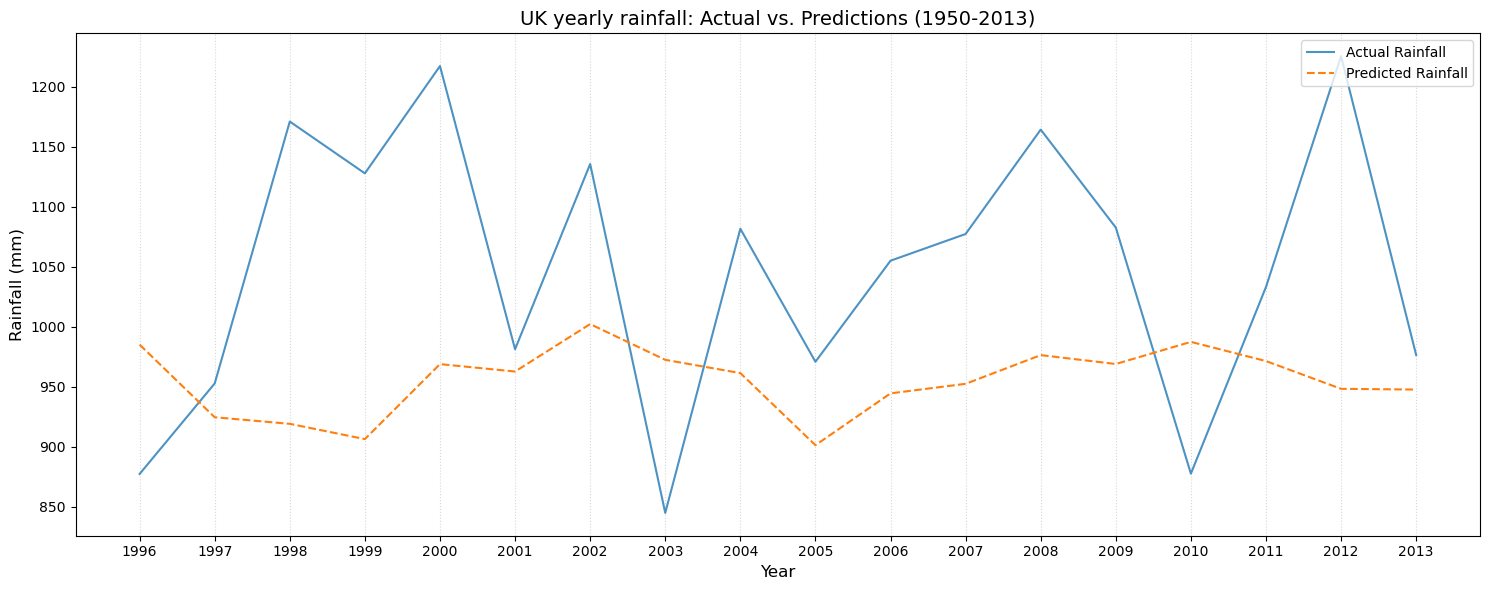

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rainfall_results(results):
    # 1. Prepare data
    years = np.array(results['year'])
    months = np.array(results['month'])
    actuals = results['actuals']
    preds = results['predictions']
    
    # Create labels for EVERY month (needed for the plot points)
    full_labels = [f"{y}-{m:02d}" for y, m in zip(years, months)]
    
    plt.figure(figsize=(15, 6))
    
    # 2. Plot lines
    plt.plot(full_labels, actuals, label='Actual Rainfall', color='#1f77b4', linewidth=1.5, alpha=0.8)
    plt.plot(full_labels, preds, label='Predicted Rainfall', color='#ff7f0e', linestyle='--', linewidth=1.5)
    
    # 3. Clean up the X-axis
    # Identify the index where each new year starts
    unique_years = np.unique(years)
    tick_indices = [np.where(years == y)[0][0] for y in unique_years]
    tick_labels = [str(y) for y in unique_years]
    
    # Set ticks to show ONLY the years
    plt.xticks(tick_indices, tick_labels, rotation=0)
    
    # 4. Styling
    plt.title(f'UK {mode} rainfall: Actual vs. Predictions (1950-2013)', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Rainfall (mm)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='x', linestyle=':', alpha=0.5) # Only vertical grid lines for years
    plt.tight_layout()
    plt.show()

# Call this in your __main__ block
plot_rainfall_results(results)
